<a href="https://colab.research.google.com/github/muhammdumairnad/Price-Driven-Demand-Prediction-in-Retail-using-Machine-Learning/blob/main/Retail_Demand_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:


# Download the dataset
dataset_path = kagglehub.dataset_download("aswathrao/demand-forecasting")

# Construct the full path to the CSV file
csv_file_path = os.path.join(dataset_path, 'train_0irEZ2H.csv')

# Read the CSV into a DataFrame
df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'demand-forecasting' dataset.


In [3]:
#EDA
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [4]:
df.shape

(150150, 9)

In [5]:
(df==" ").sum()
#there is no null or emptu value in data set

,0
record_ID,0
week,0
store_id,0
sku_id,0
total_price,0
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0


In [6]:
df.duplicated().sum()
# to check duplicated rows


np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [8]:
df[['day','month','year']] = df['week'].str.split('/', expand=True).astype(int)

In [9]:
df = df.drop('week', axis=1)

In [10]:
df.isnull().sum()

,0
record_ID,0
store_id,0
sku_id,0
total_price,1
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0
day,0
month,0


In [11]:
df['total_price'].fillna(df['base_price'], inplace=True)

In [12]:
df['store_id'].nunique()
#there are 76 stores data

76

In [13]:

df['discount'] = df['base_price'] - df['total_price']
# Fill any NaN values in discount that might arise from total_price still having NaNs before this fillna
df['discount'].fillna(0, inplace=True)

In [14]:
df['units_sold'].sort_values(ascending=False).head()

,units_sold
5607,2876
7917,1705
6762,1669
5559,1599
4917,1341


In [15]:
df.loc[[5607, 7917, 6762, 5559, 4917]]
# these are highly sold items. they are cheaper and discounted well. also ther are featured and displayed mostly

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
5607,7961,9845,219009,116.8500,227.2875,1,1,2876,14,2,11,110.4375
7917,11210,9845,219009,116.8500,227.2875,1,1,1705,28,2,11,110.4375
6762,9598,9845,219009,114.0000,227.2875,0,1,1669,21,2,11,113.2875
5559,7894,9823,219009,118.9875,227.2875,1,0,1599,14,2,11,108.3000
4917,6970,8869,219009,118.2750,225.8625,1,1,1341,14,2,11,107.5875


In [16]:
df['sku_id'].nunique()

28

In [17]:
print(df['is_featured_sku'].value_counts())
print(df['is_display_sku'].value_counts())

is_featured_sku
0    135794
1     14356
Name: count, dtype: int64
is_display_sku
0    130150
1     20000
Name: count, dtype: int64


In [18]:
df.corr()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
record_ID,1.000000,7.464429e-03,-4.772670e-04,0.008497,0.018932,0.031358,0.020428,-0.010616,-5.418852e-02,6.584549e-02,9.296388e-01,0.038649
store_id,0.007464,1.000000e+00,-6.862856e-02,-0.038308,-0.038848,-0.008729,0.013440,-0.004372,2.512449e-15,-3.199895e-15,-4.104868e-14,-0.011158
sku_id,-0.000477,-6.862856e-02,1.000000e+00,0.119327,0.119068,-0.022255,0.014911,-0.184380,-5.035883e-16,-2.503217e-15,1.196305e-14,0.027944
total_price,0.008497,-3.830780e-02,1.193275e-01,1.000000,0.958886,0.050348,-0.065935,-0.235634,8.498586e-04,-1.444323e-03,8.749467e-03,0.097633
base_price,0.018932,-3.884811e-02,1.190677e-01,0.958886,1.000000,0.214333,0.051909,-0.140032,-1.905025e-03,5.776236e-03,1.611673e-02,0.376055
is_featured_sku,0.031358,-8.729370e-03,-2.225491e-02,0.050348,0.214333,1.000000,0.426243,0.337751,-2.237073e-03,-9.845390e-04,3.036698e-02,0.587249
is_display_sku,0.020428,1.343959e-02,1.491057e-02,-0.065935,0.051909,0.426243,1.000000,0.362662,-3.063141e-03,-4.677813e-02,3.670734e-02,0.397322
units_sold,-0.010616,-4.371507e-03,-1.843798e-01,-0.235634,-0.140032,0.337751,0.362662,1.000000,-6.200682e-03,-2.303355e-03,-9.180354e-03,0.278283
day,-0.054189,2.512449e-15,-5.035883e-16,0.000850,-0.001905,-0.002237,-0.003063,-0.006201,1.000000e+00,-3.638645e-02,-7.007317e-02,-0.009456
month,0.065845,-3.199895e-15,-2.503217e-15,-0.001444,0.005776,-0.000985,-0.046778,-0.002303,-3.638645e-02,1.000000e+00,-3.050013e-01,0.024972


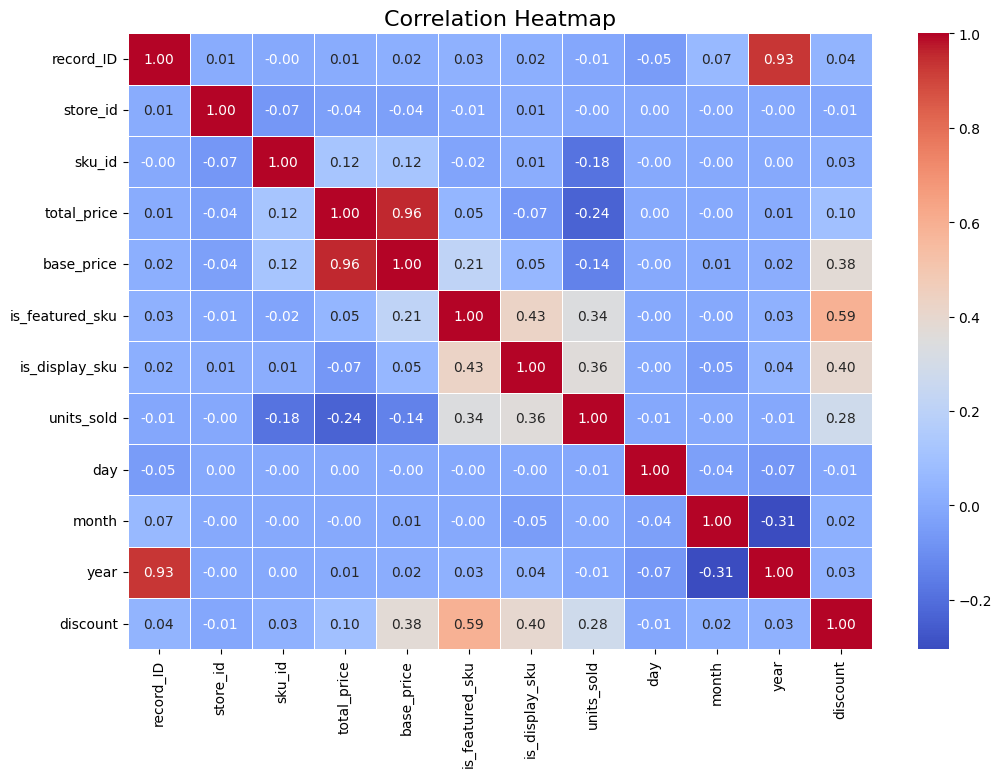

In [19]:
plt.figure(figsize=(12, 8))  # bigger heatmap

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          # 2 decimal places
    cmap='coolwarm',    # color style
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=16)

plt.show()

<Axes: xlabel='total_price', ylabel='units_sold'>

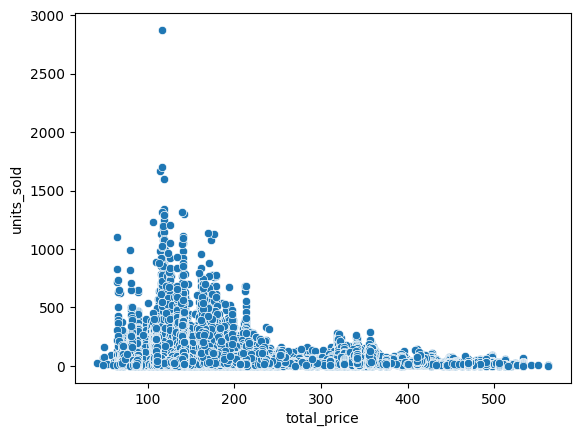

In [20]:
sns.scatterplot(x='total_price', y='units_sold', data=df)

# Lower price → more sales

<Axes: xlabel='discount', ylabel='units_sold'>

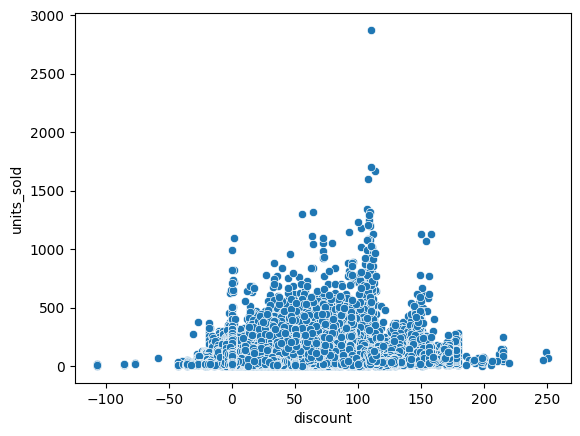

In [21]:
sns.scatterplot(x='discount', y='units_sold', data=df)
#more sales when discount is given

In [22]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
count,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.628502,219.425927,0.095611,0.133200,51.674206,15.892308,5.938462,11.830769,12.797425
std,61386.037861,615.591445,85547.306447,103.310400,110.961712,0.294058,0.339792,60.207904,8.767316,3.348384,0.755887,31.641226
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000,1.000000,1.000000,11.000000,-106.875000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000,8.000000,3.000000,11.000000,0.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000,16.000000,6.000000,12.000000,0.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000,24.000000,9.000000,12.000000,0.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000,31.000000,12.000000,13.000000,250.800000


In [23]:
(df['discount'] < 0).sum()
df.loc[df['discount'] < 0, ['base_price', 'total_price', 'discount','units_sold']]

,base_price,total_price,discount,units_sold
70,88.3500,98.3250,-9.9750,233
71,88.3500,98.3250,-9.9750,256
95,116.1375,139.6500,-23.5125,82
142,82.6500,83.3625,-0.7125,49
143,71.2500,82.6500,-11.4000,46
...,...,...,...,...
149823,86.9250,87.6375,-0.7125,31
149824,87.6375,89.0625,-1.4250,20
150056,109.0125,110.4375,-1.4250,162
150061,174.5625,175.9875,-1.4250,107


In [24]:
df.loc[[70, 71, 95, 142, 143]]

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
70,93,8023,216418,98.3250,88.3500,0,1,233,17,1,11,-9.9750
71,94,8023,216419,98.3250,88.3500,0,1,256,17,1,11,-9.9750
95,125,8058,217390,139.6500,116.1375,0,1,82,17,1,11,-23.5125
142,190,8218,216418,83.3625,82.6500,0,1,49,17,1,11,-0.7125
143,191,8218,216419,82.6500,71.2500,0,1,46,17,1,11,-11.4000


In [25]:
(df['total_price'] > df['base_price']).sum()

np.int64(3399)

In [26]:
df[df['total_price'] > df['base_price']]['units_sold'].describe()
# These represent price increases (negative discount) and may provide useful insights for model learning

,units_sold
count,3399.000000
mean,89.878788
std,66.179710
min,1.000000
25%,39.000000
50%,74.000000
75%,126.000000
max,651.000000


<Axes: xlabel='is_display_sku'>

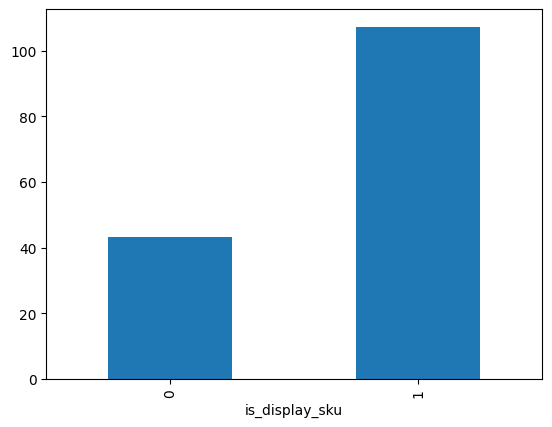

In [27]:
df.groupby('is_display_sku')['units_sold'].mean().plot(kind='bar')
# more sales for displayed items

<Axes: xlabel='is_featured_sku'>

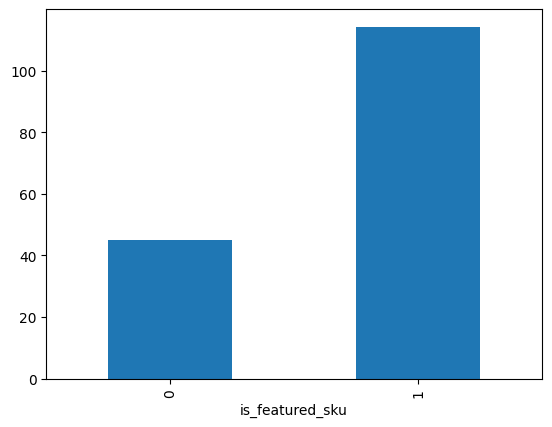

In [28]:
df.groupby('is_featured_sku')['units_sold'].mean().plot(kind='bar')
# more sales for featured items

In [29]:
# record_ID → useless
# base_price → redundant (highly correlated with total_price)
df.drop(['record_ID', 'base_price'], axis=1, inplace=True)


In [30]:
df.head()

,store_id,sku_id,total_price,is_featured_sku,is_display_sku,units_sold,day,month,year,discount
0,8091,216418,99.0375,0,0,20,17,1,11,12.825
1,8091,216419,99.0375,0,0,28,17,1,11,0.000
2,8091,216425,133.9500,0,0,19,17,1,11,0.000
3,8091,216233,133.9500,0,0,44,17,1,11,0.000
4,8091,217390,141.0750,0,0,52,17,1,11,0.000


In [31]:
df['sku_id'] = df['sku_id'].astype('category').cat.codes

In [32]:
df.drop('year', axis=1, inplace=True)

In [33]:
# Month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [34]:
df.drop(['month', 'day'], axis=1, inplace=True)

In [35]:
from sklearn.model_selection import train_test_split

# Drop rows with any remaining NaN values from the DataFrame
df.dropna(inplace=True)

X = df.drop('units_sold', axis=1)
y = df['units_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [36]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [37]:
#linear regression model
from sklearn.linear_model import LinearRegression
lg_model = LinearRegression()
lg_model.fit(X_train,y_train)

mean_squared_error_lg = mean_squared_error(y_test,lg_model.predict(X_test))
r2_score_lg = r2_score(y_test,lg_model.predict(X_test))
mean_absolute_error_lg = mean_absolute_error(y_test,lg_model.predict(X_test))

y_pred = lg_model.predict(X_test)
revenue_lg = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_lg)

print(f"Mean Squared Error: {mean_squared_error_lg}")
print(f"R2 Score: {r2_score_lg}")
print(f"Mean Absolute Error: {mean_absolute_error_lg}")




Total Revenue (Predicted): 278311582.2466994
Mean Squared Error: 2739.1900477386594
R2 Score: 0.2507917883302041
Mean Absolute Error: 30.350712330115165


In [38]:
#XGB Regressor Model
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}
xgb_model = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
xgb_model.fit(X_train,y_train)

mean_squared_error_xgb = mean_squared_error(y_test,xgb_model.predict(X_test))
r2_score_xgb = r2_score(y_test,xgb_model.predict(X_test))
mean_absolute_error_xgb = mean_absolute_error(y_test,xgb_model.predict(X_test))

y_pred = xgb_model.predict(X_test)
revenue_xgb = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_xgb)

print(f"Mean Squared Error: {mean_squared_error_xgb}")
print(f"R2 Score: {r2_score_xgb}")
print(f"Mean Absolute Error: {mean_absolute_error_xgb}")



Fitting 3 folds for each of 10 candidates, totalling 30 fits
Total Revenue (Predicted): 277546505.71013945
Mean Squared Error: 564.6116333007812
R2 Score: 0.8455705046653748
Mean Absolute Error: 13.169795036315918


In [39]:
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 10, 20]
}

lgbm_model = RandomizedSearchCV(
    lgbm,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
lgbm_model.fit(X_train,y_train)

mean_squared_error_lgbm = mean_squared_error(y_test,lgbm_model.predict(X_test))
r2_score_lgbm = r2_score(y_test,lgbm_model.predict(X_test))
mean_absolute_error_lgbm = mean_absolute_error(y_test,lgbm_model.predict(X_test))

y_pred = lgbm_model.predict(X_test)
revenue_lgbm = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_lgbm)

print(f"Mean Squared Error: {mean_squared_error_lgbm}")
print(f"R2 Score: {r2_score_lgbm}")
print(f"Mean Absolute Error: {mean_absolute_error_lgbm}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 120120, number of used features: 10
[LightGBM] [Info] Start training from score 51.574059
Total Revenue (Predicted): 277457941.37852985
Mean Squared Error: 629.454343606426
R2 Score: 0.8278351064065528
Mean Absolute Error: 14.372668474171302


In [40]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [41]:
# CatBoostRegressor Model
from catboost import CatBoostRegressor

cat = CatBoostRegressor(verbose=0)

param_grid = {
    'iterations': [200, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

cat_model = RandomizedSearchCV(
    cat,
    param_grid,
    n_iter=6,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
cat_model.fit(X_train,y_train)

mean_squared_error_cat = mean_squared_error(y_test,cat_model.predict(X_test))
r2_score_cat = r2_score(y_test,cat_model.predict(X_test))
mean_absolute_error_cat = mean_absolute_error(y_test,cat_model.predict(X_test))

y_pred = cat_model.predict(X_test)
revenue_cat = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_cat)

print(f"Mean Squared Error: {mean_squared_error_cat}")
print(f"R2 Score: {r2_score_cat}")
print(f"Mean Absolute Error: {mean_absolute_error_cat}")


Total Revenue (Predicted): 277282595.24194527
Mean Squared Error: 877.9142315036853
R2 Score: 0.7598777230052594
Mean Absolute Error: 17.020832489355985


In [42]:
# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”

In [43]:
results = pd.DataFrame({
    "Model": ["LR","XGB","LGBM","CAT"],
    "RMSE": [np.sqrt(mean_squared_error_lg), np.sqrt(mean_squared_error_xgb), np.sqrt(mean_squared_error_lgbm), np.sqrt(mean_squared_error_cat)],
    "R2": [r2_score_lg, r2_score_xgb, r2_score_lgbm, r2_score_cat],
    "MAE": [mean_absolute_error_lg, mean_absolute_error_xgb, mean_absolute_error_lgbm, mean_absolute_error_cat],
    "Revenue": [revenue_lg, revenue_xgb, revenue_lgbm, revenue_cat]
})


In [44]:
print(results)

  Model       RMSE        R2        MAE       Revenue
0    LR  52.337272  0.250792  30.350712  2.783116e+08
1   XGB  23.761558  0.845571  13.169795  2.775465e+08
2  LGBM  25.088929  0.827835  14.372668  2.774579e+08
3   CAT  29.629617  0.759878  17.020832  2.772826e+08


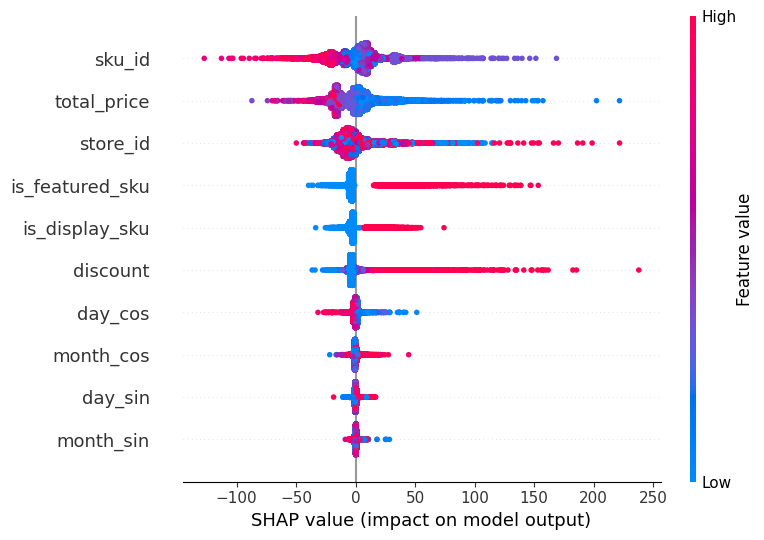

In [45]:
import shap

best_cat = cat_model.best_estimator_

explainer = shap.Explainer(best_cat)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [46]:
#SHAP analysis showed price and discount as key drivers of demand, confirming price elasticity. Promotional features like display and featured status also had strong positive impact. SKU and store IDs appeared important but represent entity-level variance rather than actionable insights.

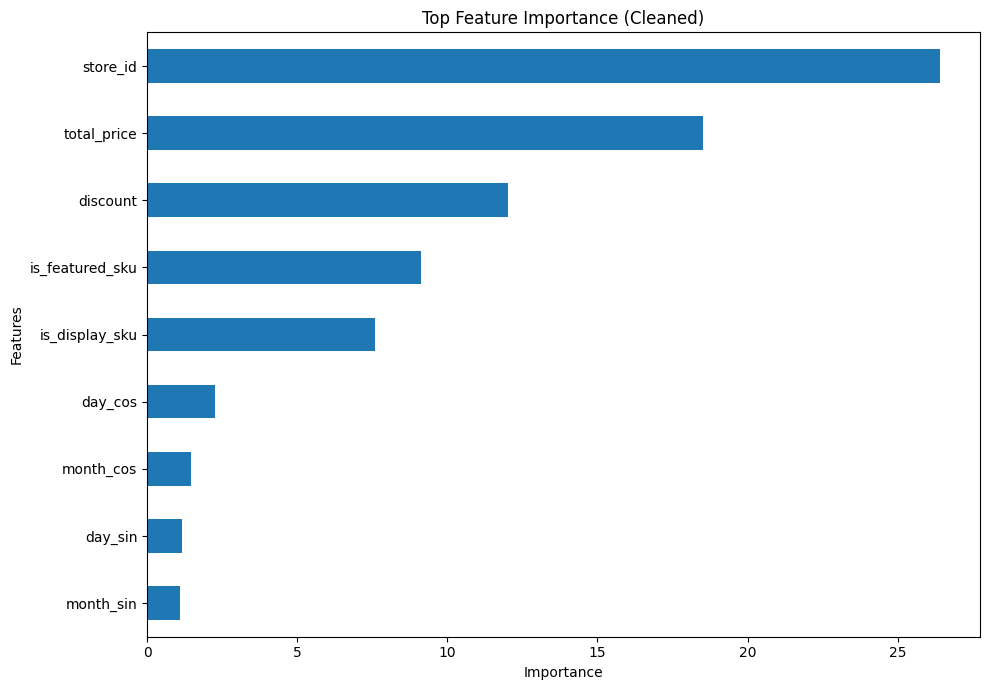

In [47]:
feat_imp = pd.Series(best_cat.feature_importances_, index=X_train.columns)

top_feat = feat_imp.sort_values(ascending=False).head(20)

# Remove sku columns
top_feat = top_feat[~top_feat.index.str.contains('sku_id')]

plt.figure(figsize=(10,7))
top_feat.sort_values().plot(kind='barh')

plt.title("Top Feature Importance (Cleaned)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”


In [48]:
# to chk which price product sold  to make maximum revenue
def optimize_price(sample_row, model):
    prices = np.linspace(
        X_test['total_price'].min(),
        X_test['total_price'].max(),
        50
    )

    best_price = None
    max_revenue = -np.inf

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        if revenue > max_revenue:
            max_revenue = revenue
            best_price = p

    return best_price, max_revenue


In [49]:

sample = X_test.iloc[20]

best_price, best_revenue = optimize_price(sample, best_cat)

print("Optimal Price:", best_price)
print("Max Revenue:", best_revenue)

Optimal Price: 174.79515306122448
Max Revenue: 7058.330507552573


In [50]:
def plot_revenue_curve(sample_row, model):
    prices = np.linspace(
    X_test['total_price'].min(),
    X_test['total_price'].max(),
    50
)
    revenues = []
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        demands.append(pred_demand)
        revenues.append(revenue)

    # Plot
    plt.figure(figsize=(10,5))
    # Revenue curve
    plt.plot(prices, revenues)
    plt.xlabel("Price (scaled)")
    plt.ylabel("Revenue")
    plt.title("Revenue vs Price Curve")
    plt.show()



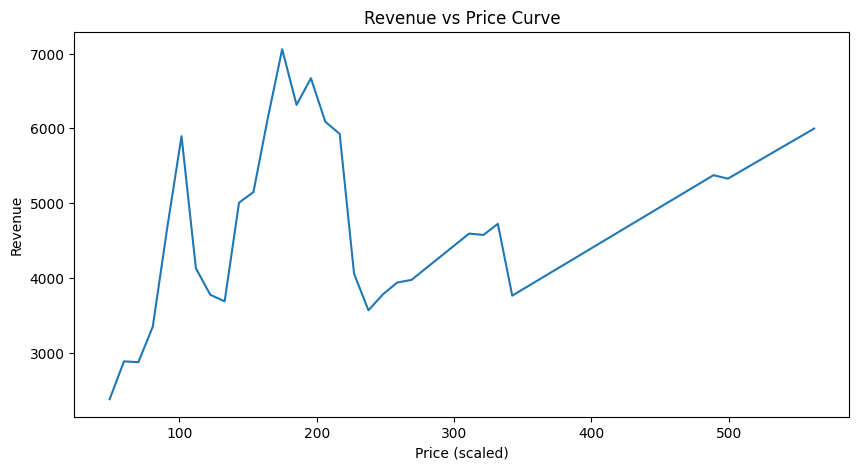

In [51]:
# Call the function to plot the revenue curve
plot_revenue_curve(sample, best_cat)

In [52]:
# peaks shows optimal prices

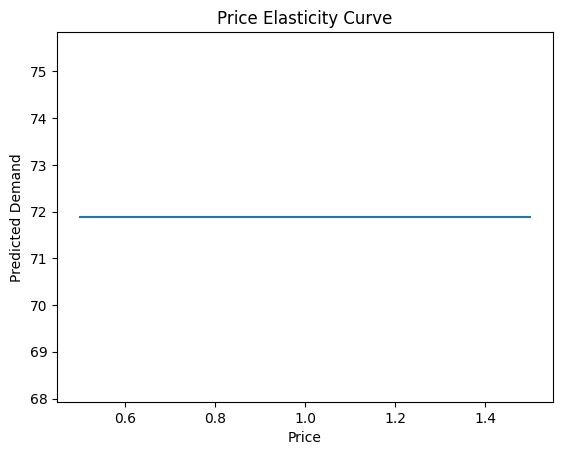

In [62]:
# Price Elasticity Graph

def plot_price_elasticity(sample_row, model):
    prices = np.linspace(0.5, 1.5, 50)
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p
        pred = model.predict([temp])[0]
        demands.append(pred)

    plt.figure()
    plt.plot(prices, demands)
    plt.xlabel("Price")
    plt.ylabel("Predicted Demand")
    plt.title("Price Elasticity Curve")
    plt.show()

sample = X_test.iloc[0]
plot_price_elasticity(sample, best_cat)

In [63]:
import joblib

# Save the best_cat model first, as it was trained earlier in the notebook
joblib.dump(best_cat, "model.pkl")

model = joblib.load("model.pkl")
# scaler = joblib.load("scaler.pkl") # No scaler was explicitly trained or saved, so this line is commented out

In [66]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.3 MB/s eta 0:00:00


In [77]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt


# Load model
model = joblib.load("model.pkl")
# scaler = joblib.load("scaler.pkl") # Removed as no scaler was trained or saved, and the model was trained on unscaled data

st.title("📊 Price-Driven Demand Prediction System")

st.write("Predict demand and optimize price using ML")

# USER INPUTS
store_id = st.number_input("Store ID", 1, 100, 1)
sku_id = st.number_input("SKU ID", 1, 5000, 1)
total_price = st.number_input("Price (£)", 1.0, 500.0, 50.0)
base_price = st.number_input("Base Price (£)", 1.0, 500.0, 60.0)
is_featured = st.selectbox("Featured?", [0,1])
is_display = st.selectbox("Display?", [0,1])

# FEATURE ENGINEERING
discount = base_price - total_price

# Removed scaling as the model was trained on unscaled data
# scaled = scaler.transform([[total_price, discount]])
# total_price_scaled = scaled[0][0]
# discount_scaled = scaled[0][1]

# sample row
input_data = pd.DataFrame({
    'store_id':[store_id],
    'sku_id':[sku_id],
    'total_price':[total_price], # Using unscaled total_price
    'is_featured_sku':[is_featured],
    'is_display_sku':[is_display],
    'discount':[discount],
    'month_sin':[0],
    'month_cos':[0],
    'day_sin':[0],
    'day_cos':[0]
})

# PREDICT
if st.button("Predict Demand"):
    demand = model.predict(input_data)[0]
    revenue = demand * total_price

    st.success(f"📦 Predicted Demand: {int(demand)} units")
    st.success(f"💰 Expected Revenue: £{revenue:.2f}")

# OPTIMIZATION
def optimize_price(sample_row):
    prices = np.linspace(10, 200, 50)
    best_price = None
    max_revenue = -np.inf
    revenues = []

    for p in prices:
        d = base_price - p
        # Removed scaling as the model was trained on unscaled data
        # scaled = scaler.transform([[p, d]])

        temp = sample_row.copy()
        temp['total_price'] = p # Using unscaled price
        temp['discount'] = d   # Using unscaled discount

        pred = model.predict(temp)[0]
        rev = p * pred

        revenues.append(rev)

        if rev > max_revenue:
            max_revenue = rev
            best_price = p

    return prices, revenues, best_price, max_revenue

if st.button("Find Optimal Price"):
    prices, revenues, best_price, max_rev = optimize_price(input_data)

    st.success(f"🎯 Optimal Price: £{best_price:.2f}")
    st.success(f"💰 Max Revenue: £{max_rev:.2f}")

    # plot
    fig, ax = plt.subplots()
    ax.plot(prices, revenues)
    ax.set_xlabel("Price (£)")
    ax.set_ylabel("Revenue")
    ax.set_title("Revenue Curve")

    st.pyplot(fig)
!streamlit run app.py

Overwriting app.py
